<a href="https://colab.research.google.com/github/TommyClaveau/modelDeforestation/blob/zob/Model_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://githubtocolab.com/BioWar/Satellite-Image-Segmentation-using-Deep-Learning-for-Deforestation-Detection/blob/main/Model_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

### Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config=config)

from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation,\
                                    MaxPool2D, UpSampling2D, concatenate,\
                                    Input, Conv2DTranspose, MaxPooling2D,\
                                    Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import tensorflow.keras as K

# config = tf.compat.v1.ConfigProto()
# config.gpu_options.allow_growth = True
# sess = tf.compat.v1.Session(config=config)

from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from numba import cuda
import datetime
import copy
import PIL
import sys
import random
import os
from matplotlib import colors

from tensorflow.keras import backend as K

# random.seed(42)
# tf.random.set_seed(42)
# np.random.seed(42)

import matplotlib.pyplot as plt
import numpy as np
from numba import cuda
import datetime

### Utils


In [2]:
def conv2d_block(input_tensor, n_filters, kernel_size=3, batchnorm=True, sublayers=2):
    '''In case batchnorm=False "if" statement will be skipped and in amount of "sublayers" convolutional layers will be created.'''
    for idx in range(sublayers):
        conv = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size),
                   kernel_initializer="he_normal", padding="same")(input_tensor if idx==0 else conv)
        if batchnorm:
            normalized = BatchNormalization()(conv)
        conv = Activation("relu")(conv) # normalized to conv
    return conv

def conv2d_transpose_block(input_tensor, concatenate_tensor, n_filters, kernel_size=3, strides=2, transpose=False):
    if transpose:
        conv = Conv2DTranspose(n_filters, (kernel_size, kernel_size),
                               strides=(strides, strides), padding='same')(input_tensor)
    else:
        conv = Conv2D(n_filters, (kernel_size, kernel_size), activation = 'relu', padding = 'same',
                      kernel_initializer = 'he_normal')(UpSampling2D(size=(kernel_size, kernel_size))(input_tensor))
    conv = Activation("relu")(conv)
    concatenation = concatenate([conv, concatenate_tensor])
    return concatenation

def build_unet(input_shape=(512, 512, 3), filters=[16, 32, 64, 128, 256], batchnorm=True, transpose=False, dropout_flag=False):  # dropout_rate=0.2

    conv_dict = dict()
    inputs = Input(input_shape)
    dropout_rate = 0.5

    for idx, n_filters in enumerate(filters[:-1]):
        conv = conv2d_block(inputs if n_filters==filters[0] else max_pool, # Change max_pool to dropout
                            n_filters=n_filters, kernel_size=3,
                            batchnorm=batchnorm)
        max_pool = MaxPooling2D((2, 2))(conv)
        # Commented dropout
#         if idx > 1 and dropout_flag:
#             print('[INFO] Dropout down')
#             dropout = Dropout(dropout_rate)(max_pool)
#         else:
#             print('[INFO] Dropout down skip')
#             dropout = max_pool
#         print(f'[INFO] Conv block {idx} created.')
        # Save layer
        conv_dict[f"conv2d_{idx+1}"] = conv

    # Change max_pool to dropout
    conv_middle = conv2d_block(max_pool, n_filters=filters[-1], kernel_size=3, batchnorm=batchnorm)

    for idx, n_filters in enumerate(reversed(filters[:-1])):
        concatenation = conv2d_transpose_block(conv_middle if idx==0 else conv,
                                               conv_dict[f"conv2d_{len(conv_dict) - idx}"],
                                               n_filters, kernel_size=2, strides=2, transpose=transpose) # kernel_size=2, like in previous
        # Commented Dropout
#         if idx < len(filters) - 3 and dropout_flag:
#             print('[INFO] Dropout up')
#             dropout = Dropout(dropout_rate)(concatenation)
#         else:
#             print('[INFO] Dropout up skip')
#             dropout = concatenation
        conv = conv2d_block(concatenation, n_filters=n_filters, kernel_size=3, # Change concatenation to Dropout
#                             batchnorm = batchnorm if idx not in [len(conv_dict), len(conv_dict) - 1] else False)
                              batchnorm = batchnorm)
        print(f'[INFO] UpConv block {idx} created.')
    outputs = Conv2D(3, (1, 1), activation='softmax')(conv)
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [3]:
def make_unet_experimental():
  input_size = (512, 512,3)
  inputs = Input(input_size)

  conv1 = Conv2D(16, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(inputs)
  conv1 = Conv2D(16, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv1)
  pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

  conv2 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool1)
  conv2 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv2)
  up2_1  = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(conv2))
  pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

  conv3 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool2)
  conv3 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv3)
  up3_1  = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(conv3))
  up3_2  = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(up3_1))
  pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

  conv4 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool3)
  conv4 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv4)
  up4_1  = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(conv4))
  up4_2  = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(up4_1))
  up4_3  = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(up4_2))
  pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

  conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool4)
  conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv5)
  up5_1 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(conv5))
  up5_2 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(up5_1))
  up5_3 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(up5_2))
  up5_4 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2,2))(up5_3))

  up6 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv5))
  merge6 = concatenate([conv4, up6, up5_1], axis = 3)
  conv6 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
  conv6 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv6)

  up7 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv6))
  merge7 = concatenate([conv3, up7, up5_2, up4_1], axis = 3)
  conv7 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge7)
  conv7 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv7)

  up8 = Conv2D(32, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv7))
  merge8 = concatenate([conv2, up8, up5_3, up4_2, up3_1], axis = 3)
  conv8 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge8)
  conv8 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv8)

  up9 = Conv2D(16, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv8))
  merge9 = concatenate([conv1, up9, up5_4, up4_3, up3_2, up2_1], axis = 3)
  conv9 = Conv2D(16, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge9)
  conv9 = Conv2D(16, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv9)

  conv10 = Conv2D(3, 1, activation = 'softmax')(conv9)

  model = Model(inputs = inputs, outputs = conv10)
  return model

### Connect Colab

In [4]:
from google.colab import drive

drive.mount("/content/gdrive")

from google.colab import auth
auth.authenticate_user()

project_id = 'sustained-valor-300008'
!gcloud config set project {project_id}
!gsutil ls

Mounted at /content/gdrive
Are you sure you wish to set property [core/project] to sustained-valor-300008?

Do you want to continue (Y/n)?  y

Updated property [core/project].
BadRequestException: 400 Project id: 0 is invalid or not found


In [5]:
final_filters = 2048

# model7 = build_unet(input_shape=(512, 512, 3),
#                      filters=[2 ** i for i in range(5, int(np.log2(final_filters) + 1))], # Amount of filters in U-Net arch.
#                      batchnorm=False, transpose=False, dropout_flag=False)

# model8 = build_unet(input_shape=(512, 512, 3),
#                      filters=[2 ** i for i in range(5, int(np.log2(final_filters) + 1))], # Amount of filters in U-Net arch.
#                      batchnorm=False, transpose=False, dropout_flag=False)

# model9 = build_unet(input_shape=(512, 512, 3),
#                      filters=[2 ** i for i in range(5, int(np.log2(final_filters) + 1))], # Amount of filters in U-Net arch.
#                      batchnorm=False, transpose=False, dropout_flag=False)


model10 = build_unet(input_shape=(1024, 1024, 3),
                     filters=[2 ** i for i in range(5, int(np.log2(final_filters) + 1))], # Amount of filters in U-Net arch.
                     batchnorm=False, transpose=False, dropout_flag=False)

[INFO] UpConv block 0 created.
[INFO] UpConv block 1 created.
[INFO] UpConv block 2 created.
[INFO] UpConv block 3 created.
[INFO] UpConv block 4 created.
[INFO] UpConv block 5 created.


In [6]:
# model10.summary()
# [2 ** i for i in range(5, int(np.log2(final_filters) + 1))]

In [7]:
# model1 = tf.keras.models.load_model("/content/gdrive/MyDrive/Models/TPU/model_tpu_16_v1_u4.h5")
# model2 = tf.keras.models.load_model("/content/gdrive/MyDrive/Models/TPU/model_tpu_16_v1_u7.h5")
# model3 = tf.keras.models.load_model("/content/gdrive/MyDrive/Models/TPU/model_tpu_16_v1_u9.h5")
# model4 = tf.keras.models.load_model("/content/gdrive/MyDrive/Models/TPU/model_tpu_32_v1_u10.h5")
# model5 = tf.keras.models.load_model("/content/gdrive/MyDrive/Models/TPU/model_tpu_2048_16_v1_u2.h5")

# path_to_load = "/content/gdrive/MyDrive/Models/TPU/model_tpu_2048_16_v5/U5_E:1201-F1:0.6982-IOU:0.6340.h5"
# model8.load_weights(path_to_load)

# path_to_load = "/content/gdrive/MyDrive/Models/TPU/model_tpu_2048_16_v5/U6_E:1201-F1:0.7134-IOU:0.6555.h5"
# model9.load_weights(path_to_load)

path_to_load = "/content/gdrive/MyDrive/U6_E_1201-F1_0.7134-IOU_0.6555.h5"
model10.load_weights(path_to_load)

# path_to_load_exp = "/content/gdrive/MyDrive/Models/TPU/model_tpu_1024_8_v6/U2_E:0301-F1:0.5274-IOU:0.4797.h5"
# model.load_weights(path_to_load_exp)

In [8]:
# from PIL import Image

# image1 = Image.open('/content/gdrive/MyDrive/Dataset/dataset_08_04_2021/data_shaffled_8_04_2021/images/1.png')
# image2 = Image.open('/content/gdrive/MyDrive/Dataset/dataset_08_04_2021/data_shaffled_8_04_2021/images/2.png')
# image3 = Image.open('/content/gdrive/MyDrive/Dataset/dataset_08_04_2021/data_shaffled_8_04_2021/images/6.png')
# image4 = Image.open('/content/gdrive/MyDrive/Dataset/dataset_08_04_2021/data_shaffled_8_04_2021/images/7.png')

In [9]:
# i1 = np.array(image1)
# i2 = np.array(image2)
# i3 = np.array(image3)
# i4 = np.array(image4)

# i12 = np.concatenate((i1, i2), axis=1)
# i34 = np.concatenate((i3, i4), axis=1)
# image_1024 = np.concatenate((i12, i34), axis=0)
# image_1024 = image_1024[np.newaxis, ...]
# image_1024.shape

In [10]:
# pred = model10.predict(image_1024)

In [11]:
# plt.imshow(pred[0])

In [12]:
# model101 = build_unet(input_shape=(512, 512, 3),
#                      filters=[2 ** i for i in range(5, int(np.log2(final_filters) + 1))], # Amount of filters in U-Net arch.
#                      batchnorm=False, transpose=False, dropout_flag=False)
# path_to_load = "/content/gdrive/MyDrive/Models/TPU/model_tpu_2048_16_v5/U6_E:1201-F1:0.7134-IOU:0.6555.h5"
# model101.load_weights(path_to_load)

In [13]:
# plt.imshow(model101.predict(i1[np.newaxis, ...])[0])

In [14]:
from PIL import Image
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def preprocess_one_hot_encode(image_rgb):
    img = np.copy(image_rgb[..., 0])
    for i, num in enumerate([11, 226, 51]):
        img[img == num] = i
    one_hot = tf.keras.utils.to_categorical(img, 3)
    return one_hot

def load_raw_images(y_path):
    Y = []
    for filename in os.listdir(y_path):
        if filename.endswith("png"):
            Y.append(filename)
    return Y

def load_test_images(path):
    images = load_raw_images(path)
    np_images = []
    for image in images:
        im_x = Image.open(f"{path}/{image}")
        im_x_np = np.asarray(im_x, dtype="float32") / 255.0
        np_images.append(im_x_np)
    return np_images

def get_predictions(model, images):
    predictions = []
    for image in images:
        prediction = model.predict(image[np.newaxis, ...])
        predictions.append(prediction)
    return predictions

def delete_transparancy(path):
    image = Image.open(path)
    new_image = Image.new("RGBA", image.size, "WHITE") # Create a white rgba background
    new_image.paste(image, (0, 0), image)              # Paste the image on the background. Go to the links given below for details.
    new_image.convert('RGB').save('test.png', "PNG")

def plot_predictions(models, images, masks, flags):
    model_names = list(models.keys())
    models = list(models.values())
    fig, ax = plt.subplots(ncols=len(models)+2,
                           nrows=len(images),
                           figsize=(8*len(models),4*len(images)),
                           sharex=True, sharey=True)
    x_ax = []
    df_ax = pd.DataFrame.from_records(ax)
    # Plot initial images
    for i, im in enumerate(images):
        df_ax.iloc[i][0].imshow(im)
        if i == 0:
            df_ax.iloc[i][0].title.set_text(f'Test Images')
    # Plot ground truth masks
    for i, im in enumerate(masks):
        im = im.numpy()
        prediction_class1 = np.copy(im[..., 0]) # Forest
        prediction_class2 = np.copy(im[..., 1]) # Deforest
        im[..., 0] = prediction_class2 # RED - Deforest
        im[..., 1] = prediction_class1 # GREEN - Forest
        df_ax.iloc[i][1].imshow(im)
        if i == 0:
            df_ax.iloc[i][1].title.set_text(f'Ground Truth')
    # Plot predictions
    for i, model in enumerate(models):
        for j, image in enumerate(images):
            image = image[np.newaxis, ...]
            prediction = model.predict(image)
            if flags[i] == True:
                prediction_class1 = np.copy(prediction[..., 0]) # Forest
                prediction_class2 = np.copy(prediction[..., 1]) # Deforest
                prediction[..., 0] = prediction_class2 # RED - Deforest
                prediction[..., 1] = prediction_class1 # GREEN - Forest
            df_ax.iloc[j][i+2].imshow(prediction[0]) # i + 1 because 0 column is complete. UPDATE: i + 2 because 1 column is gt
            if j == 0:
                df_ax.iloc[j][i+2].title.set_text(f'{model_names[i]}')
            df_ax.iloc[j][i+2].set_xticklabels([])
            df_ax.iloc[j][i+2].set_yticklabels([])
            print(f"[INFO] Image {j+1}/{len(images)}, model{i}.")

    print("[INFO] Finished!")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.savefig("Predictions.png", dpi=100)
    return df_ax

def get_example(dataset_path, image_num):
  raw_image_dataset = tf.data.TFRecordDataset(dataset_path)
  # Create a dictionary describing the features.
  image_feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "mask": tf.io.FixedLenFeature([], tf.string),
  }

  def _parse_image_function(example_proto):
    # Parse the input tf.train.Example proto using the dictionary above.
    return tf.io.parse_single_example(example_proto, image_feature_description)

  parsed_image_dataset = raw_image_dataset.map(_parse_image_function)
  for image_features in parsed_image_dataset:
    if image_num != 0:
      image_raw = image_features['image'].numpy()
      mask_raw = image_features['mask'].numpy()
      image_num -= 1
    else:
      break
  image = tf.image.decode_png(image_raw, channels=3)
  image = tf.image.resize(image, [512, 512])
  image = tf.cast(image, tf.float32) / 255.0  # convert image to floats in [0, 1] range
  mask = tf.io.decode_raw(mask_raw, out_type="float")
  mask = tf.reshape(mask, [512, 512, 3])
  mask = tf.cast(mask, tf.float32)
  return image, mask

def get_example_images_only(dataset_path, index):
    raw_dataset = tf.data.TFRecordDataset(dataset_path)
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
    }

    def _parse_function(example_proto):
        return tf.io.parse_single_example(example_proto, feature_description)

    parsed_dataset = raw_dataset.map(_parse_function)

    for i, features in enumerate(parsed_dataset):
        if i == index:
            image_raw = features["image"].numpy()
            image = tf.image.decode_image(image_raw, channels=3)
            image = tf.image.resize(image, [1024, 1024])  # resize to your model input
            image = tf.cast(image, tf.float32) / 255.0
            return image
    raise IndexError(f"Index {index} out of range")


In [15]:
import tensorflow as tf
import os

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def create_tfrecord_from_images(image_folder, output_path):
    with tf.io.TFRecordWriter(output_path) as writer:
        for filename in sorted(os.listdir(image_folder)):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(image_folder, filename)
                image = tf.io.read_file(img_path)
                example = tf.train.Example(features=tf.train.Features(feature={
                    "image": _bytes_feature(image.numpy())
                }))
                writer.write(example.SerializeToString())
                print(f"[INFO] Added {filename}")
    print(f"\n✅ TFRecord created at: {output_path}")

# Example usage
image_folder = "/content/gdrive/MyDrive/images_deforestation"  # change this to your image folder
output_path = "/content/gdrive/MyDrive/my_dataset/my_dataset.tfrecord"

create_tfrecord_from_images(image_folder, output_path)


[INFO] Added paf.png
[INFO] Added paf3.png
[INFO] Added paf4.png

✅ TFRecord created at: /content/gdrive/MyDrive/my_dataset/my_dataset.tfrecord


In [16]:
import os

path = "/content/gdrive/MyDrive/my_dataset/my_dataset.tfrecord"

print("File exists:", os.path.exists(path))
print("File size (bytes):", os.path.getsize(path) if os.path.exists(path) else "N/A")
count = 0
for _ in tf.data.TFRecordDataset(path):
    count += 1
print("Number of images in TFRecord:", count)

File exists: True
File size (bytes): 552965
Number of images in TFRecord: 3


[INFO] Added image 0.
[INFO] Added image 1.
[INFO] Added image 2.
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


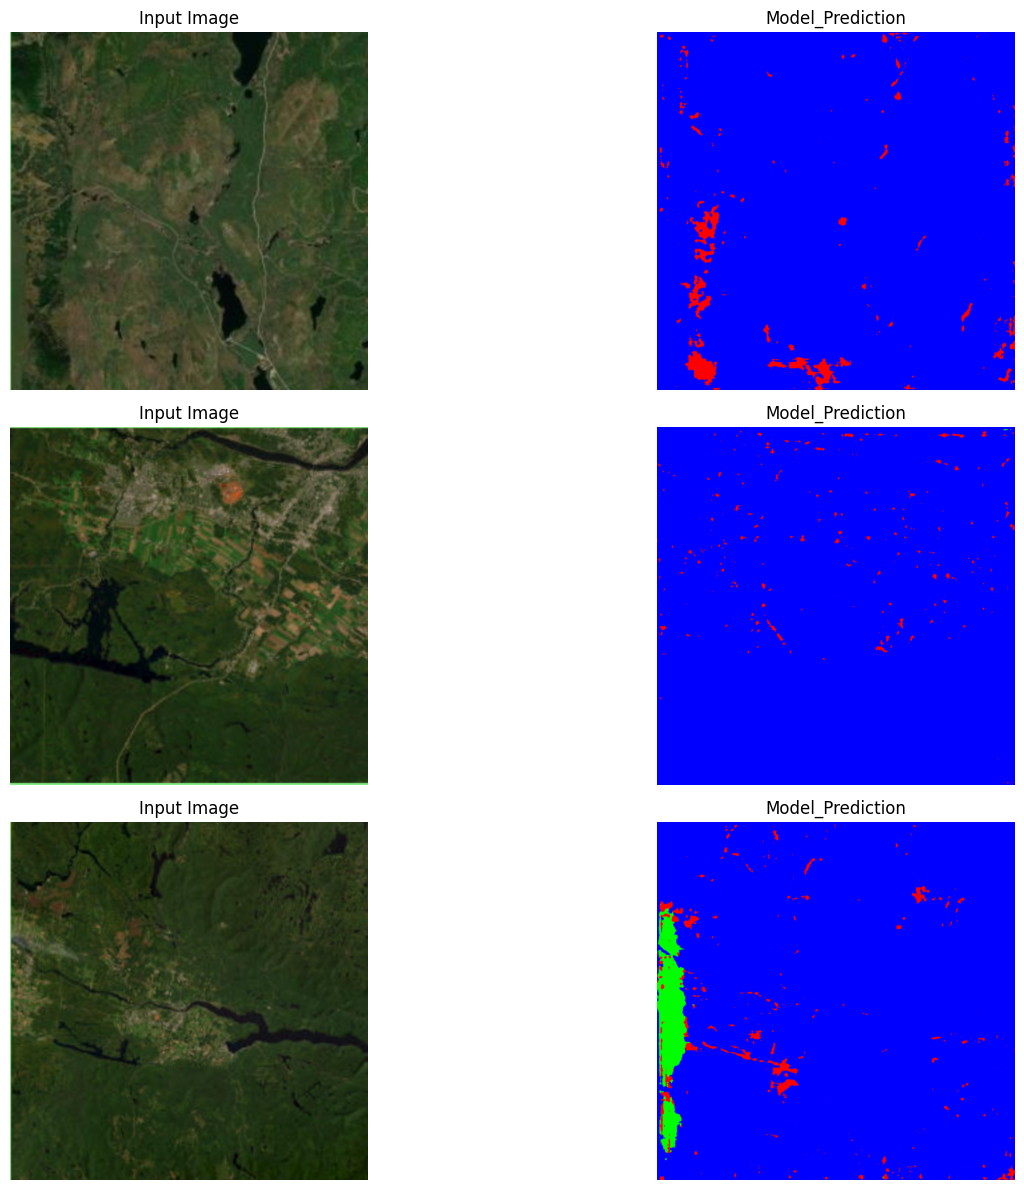

In [17]:
path = "/content/gdrive/MyDrive/my_dataset/my_dataset.tfrecord"

# Load all images from TFRecord
images = []
for i in range(count):  # or however many images you want
    image = get_example_images_only(path, i)
    images.append(image)
    print(f"[INFO] Added image {i}.")

models = {#"Final Model": model_final,
          #"Dropout Model": model_dropout,
          # "Model1": model1,
          # "Model2": model2,
          # "Model3": model3,
          # "Model5": model5,
          # "Model_New_Dataset_1": model8,
          # "Model_New_Dataset_2": model9,
          "Model_Prediction": model10,
#           "Model Weighted Balanced Final": model_weighted_balanced_final,
#           "Model Hybrid 4": model_hybrid4,
#           "Model Weighted Balanced": model_weighted_balanced,
#           "Model Categorical": model_final,
#            'Model Baseline': model_initial
}

# Plot predictions (no masks available)
fig, ax = plt.subplots(
    ncols=len(models) + 1,
    nrows=len(images),
    figsize=(8 * (len(models) + 1), 4 * len(images)),
    sharex=True, sharey=True
)

# Always make `ax` a 2D array, even if nrows == 1
if len(images) == 1:
    ax = np.expand_dims(ax, axis=0)
if len(models) == 0:
    ax = np.expand_dims(ax, axis=1)

model_names = list(models.keys())
model_list = list(models.values())

# Plot input images
for i, im in enumerate(images):
    ax[i, 0].imshow(im)
    ax[i, 0].set_title("Input Image")
    ax[i, 0].axis("off")

# Plot model predictions
for j, model in enumerate(model_list):
    for i, image in enumerate(images):
        # ✅ Resize to model's expected input size
        resized_image = tf.image.resize(image, [1024, 1024])
        prediction = model.predict(resized_image[np.newaxis, ...])[0]

        ax[i, j + 1].imshow(prediction)
        ax[i, j + 1].set_title(model_names[j])
        ax[i, j + 1].axis("off")

plt.tight_layout()
plt.show()


✅ TFRecord contains 3 image(s).
[INFO] Added image 0.
[INFO] Added image 1.
[INFO] Added image 2.


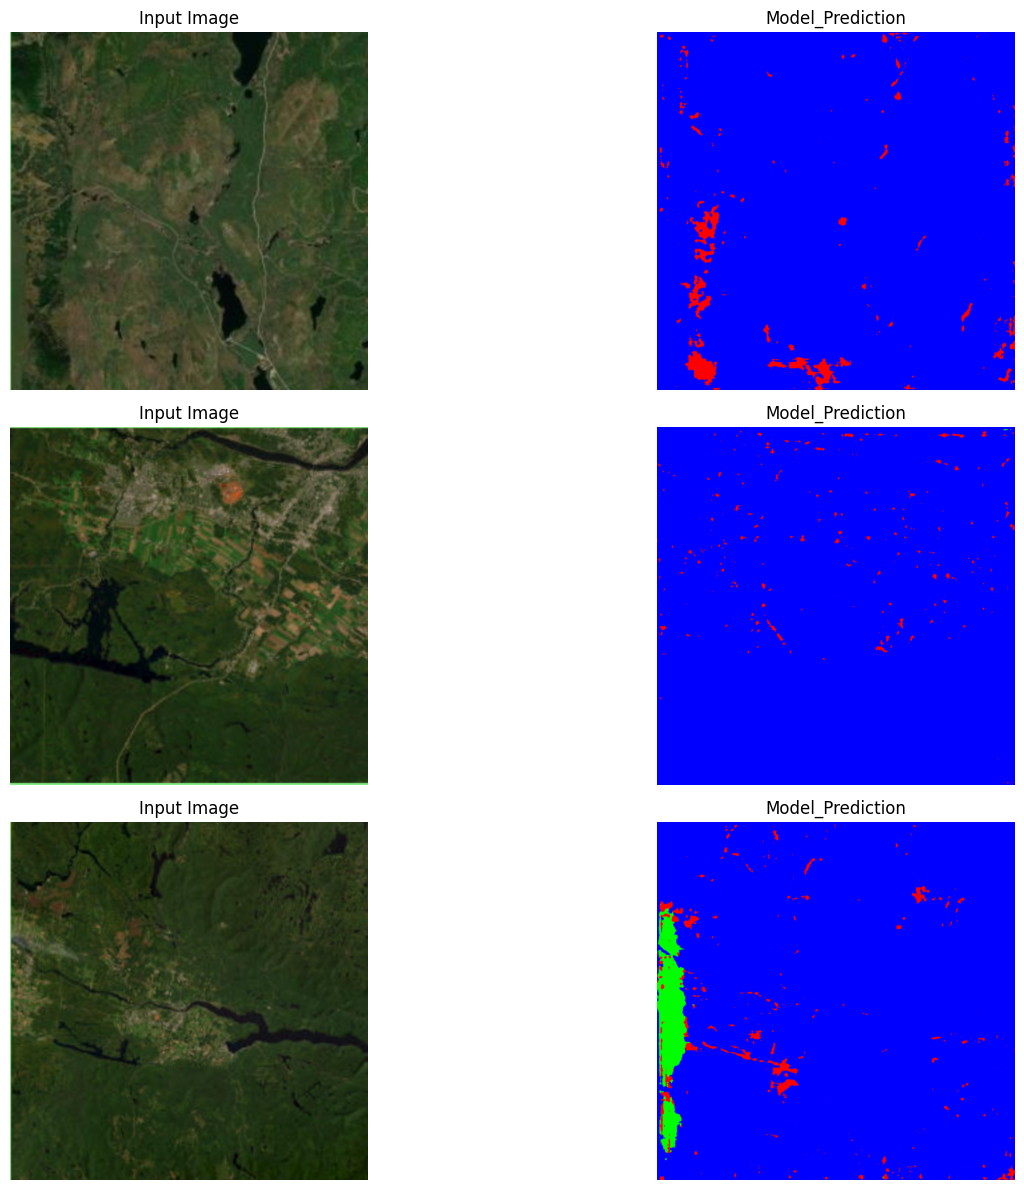

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

path = "/content/gdrive/MyDrive/my_dataset/my_dataset.tfrecord"

count = sum(1 for _ in tf.data.TFRecordDataset(path))
print(f"✅ TFRecord contains {count} image(s).")

# Load only available ones
images = []
for i in range(count):  # not range(1, 23)
    image = get_example_images_only(path, i)
    images.append(image)
    print(f"[INFO] Added image {i}.")

# --- Define models ---
models = {
    "Model_Prediction": model10  # or model, whichever you're testing
}

# --- Create subplot ---
fig, ax = plt.subplots(
    ncols=len(models) + 1,
    nrows=len(images),
    figsize=(8 * (len(models) + 1), 4 * len(images)),
    sharex=True, sharey=True
)

# Ensure ax is always 2D (Matplotlib flattens if nrows == 1)
if len(images) == 1:
    ax = np.expand_dims(ax, axis=0)

model_names = list(models.keys())
model_list = list(models.values())

# --- Plot input images ---
for i, im in enumerate(images):
    ax[i, 0].imshow(im)
    ax[i, 0].set_title("Input Image")
    ax[i, 0].axis("off")

# --- Plot model predictions ---
for j, model in enumerate(model_list):
    for i, image in enumerate(images):
        # ✅ Resize to match model input (1024x1024)
        resized_image = tf.image.resize(image, [1024, 1024])
        resized_image = tf.expand_dims(resized_image, axis=0)  # add batch dim
        prediction = model.predict(resized_image, verbose=0)[0]

        ax[i, j + 1].imshow(prediction)
        ax[i, j + 1].set_title(model_names[j])
        ax[i, j + 1].axis("off")

plt.tight_layout()
plt.show()


[INFO] Added image 0
[INFO] Added image 1
[INFO] Added image 2


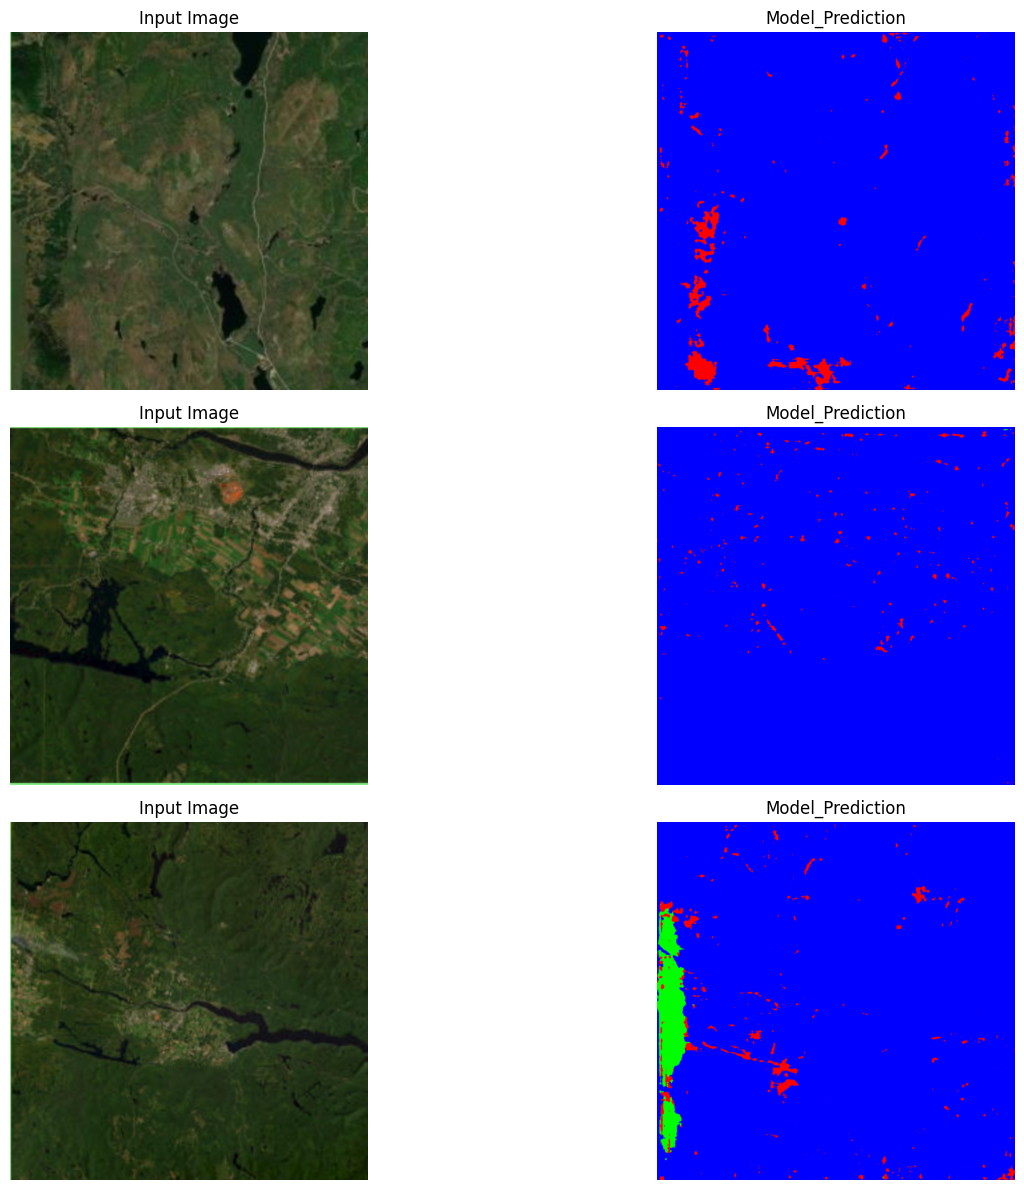

In [19]:
path = "/content/gdrive/MyDrive/my_dataset/my_dataset.tfrecord"

# Load images
images = []
count = sum(1 for _ in tf.data.TFRecordDataset(path))
for i in range(count):
    img = get_example_images_only(path, i)
    images.append(img)
    print(f"[INFO] Added image {i}")

# Models dictionary
models = {"Model_Prediction": model10}

# Create subplot grid
fig, ax = plt.subplots(
    ncols=len(models) + 1,
    nrows=len(images),
    figsize=(8 * (len(models) + 1), 4 * len(images)),
    sharex=True,
    sharey=True
)

# Ensure ax is 2D even if only one image
if len(images) == 1:
    ax = np.expand_dims(ax, axis=0)

model_names = list(models.keys())
model_list = list(models.values())

# Plot input images
for i, im in enumerate(images):
    ax[i, 0].imshow(im)
    ax[i, 0].set_title("Input Image")
    ax[i, 0].axis("off")

# Plot predictions
for j, model in enumerate(model_list):
    for i, image in enumerate(images):
        resized_image = tf.image.resize(image, [1024, 1024])
        prediction = model.predict(tf.expand_dims(resized_image, axis=0), verbose=0)[0]
        ax[i, j + 1].imshow(prediction)
        ax[i, j + 1].set_title(model_names[j])
        ax[i, j + 1].axis("off")

plt.tight_layout()
plt.show()


[INFO] Image 0: Percent of deforestation: 3.05%


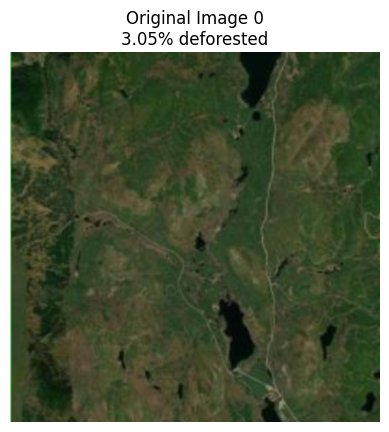

[INFO] Image 1: Percent of deforestation: 0.89%


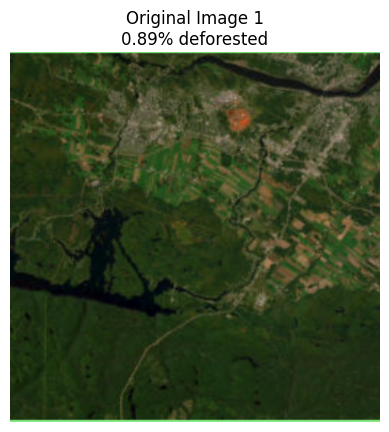

[INFO] Image 2: Percent of deforestation: 2.03%


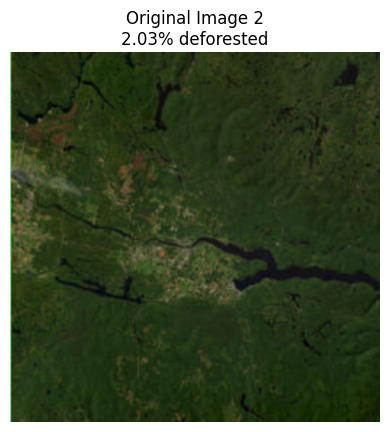

In [20]:
for idx, image_orig in enumerate(images):
    # Add batch dimension
    image = image_orig[np.newaxis, ...]

    # Run the model prediction
    prediction = model10.predict(image, verbose=0)

    # Swap channels to highlight RED = deforest, GREEN = forest
    prediction_class1 = np.copy(prediction[..., 0])  # Forest
    prediction_class2 = np.copy(prediction[..., 1])  # Deforest
    prediction[..., 0] = prediction_class2  # RED - Deforest
    prediction[..., 1] = prediction_class1  # GREEN - Forest

    # --- Calculate percent deforestation ---
    pred_class = np.argmax(prediction[0], axis=-1)  # shape: (H, W)
    deforested_pixels = np.sum(pred_class == 1)  # assuming class 1 = deforested
    total_pixels = pred_class.size
    percent_deforestation = (deforested_pixels / total_pixels) * 100

    print(f"[INFO] Image {idx}: Percent of deforestation: {percent_deforestation:.2f}%")

    # --- Plot the original image ---
    plt.imshow(image_orig)
    plt.title(f"Original Image {idx}\n{percent_deforestation:.2f}% deforested")
    plt.axis("off")
    plt.show()


In [21]:
# raise

In [22]:
#delete_transparancy("Predictions.png")

In [23]:
#X, Y = np.load('X__test.npy'), np.load('Y__test.npy')
#print(f"[INFO] X.shape = {X.shape}, Y.shape = {Y.shape}")
#print(f"[INFO] Amount of examples in test dataset: {X.shape[0]}")